<a href="https://colab.research.google.com/github/predicthq/phq-data-science-docs/blob/master/unattended-events/part_2_data_exploration.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### NON-ATTENDANCE-BASED EVENTS DATA SCIENCE GUIDES

# Part 2 Data Exploration
<b>A How To Guide to exploring PredictHQ's Non-Attendance-Based Events (public-holidays, observances and school-holidays).</b>

- [SDK or CSV Data Access](#csv_sdk)
- [Query Non-Attendance-Based Events](#query_unattended_events)
- [Overview of Non-Attendance-Based Events](#event_overview)
- [Event Label Statistics](#event_labels)
- [PHQ Rank and Aviation Rank](#ranks)
- [Duration](#duration)
- [First Seen Date](#first_seen_date_start_date)
- [Map Visualization](#visual_map)
- [Impact of Radius Settings](#radius_impact)
- [Comparing with Third Party Libraries](#comparing_with_third_party_libraries)
- [Forecasting Impact](#forecasting_impact)


If using Google Colab uncomment the following code block.

In [2]:
# %%capture
# !git clone https://github.com/predicthq/phq-data-science-docs.git
# %cd phq-data-science-docs/unattended-events
# !pip install predicthq timezonefinder calmap==0.0.8 pandas==1.0.5


If running locally, set up a Python environment using `requirements.txt` shared alongside the notebook to install the required dependencies. 



In [3]:
from predicthq import Client
from timezonefinder import TimezoneFinder
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import folium
from datetime import timedelta
import calmap
import requests
import json
import passwords
import geopandas as gpd
from shapely.geometry import shape
import fbprophet
%matplotlib inline

# To display more columns in the DataFrame
pd.set_option("display.max_columns", 50)

<a id='csv_sdk'></a>
# SDK or CSV Data Access
This notebook can be run using both the csv example data provided, or if you have access to the PredictHQ Client endpoint, you can use the code provided to call the SDK for the locations of interest to you. 

The starting point for Part 2 is the dataset created at the end of Part 1. As using the SDK is not the focus of Part 2, a function is created to call the SDK. For guidance on how to use the SDK, please refer to Part 1. If you do not have access to the SDK, the notebook also works with a number of CSV files that are provided alongside the notebook. 

In [4]:
# Set whether to run with SDK or using provided CSV files
# Set to either 'CSV' or 'SDK'
RUN_SETTING = "SDK"

if RUN_SETTING == "SDK":
    # Replace Access Token with own access token.
    ACCESS_TOKEN = 'ACCESS_TOKEN'
    phq = Client(access_token=ACCESS_TOKEN)


def query_unattended_events(
    start_time,
    end_time,
    radius,
    radius_unit,
    latitude,
    longitude,
    categories,
):
    """
    Query Non-Attendance-Based Events based on time, location and category info.
    Args:
        start_time: start of the period for querying Non-Attendance-Based Events.
                    Format "YYYY-MM-DD"
        end_time: end of the period for querying Non-Attendance-Based Events.
                    Format of "YYYY-MM-DD"
        radius: radius for querying Non-Attendance-Based Events.
        radius_unit: unit of the radius.
        latitude: latitude of the interested location.
        longitude: longitude of the interested location.
        categories: list of categories, such as
                                    ['school-holidays',
                                    'public-holidays',
                                    'observances']
    return:
        event_df: pandas DataFrames of non-attendance-based events
    """
    within = f"{radius}{radius_unit}@{latitude},{longitude}"
    timezone = TimezoneFinder().timezone_at(lat=latitude, lng=longitude)

    params = {
        "active__gte": start_time,
        "active__lte": end_time,
        "active__tz": timezone,
        "within": within,
        "category": categories,
    }

    result_list = []

    # Iterating through all the events that match our criteria and
    # adding them to our result_list
    for event in phq.events.search(**params).iter_all():
        result_list.append(event.model_dump())

    event_df = pd.DataFrame(result_list)
    # Selecting the target fields
    event_df = event_df[
        [
            "id",
            "title",
            "description",
            "start",
            "end",
            "duration",
            "category",
            "labels",
            "country",
            "rank",
            "aviation_rank",
            "phq_attendance",
            "geo",
            "local_rank",
            "location",
            "place_hierarchies",
            "scope",
            "first_seen",
        ]
    ]
    return event_df

<a id='query_unattended_events'></a>
# Query Non-Attendance-Based Events

In [5]:
start_time = "2020-01-01"
end_time = "2020-12-31"
radius = 10
radius_unit = "km"
latitude, longitude = (34.07, -118.25)
categories = ["school-holidays", "public-holidays", "observances"]
file_name = f"data/event_data/radius{radius}{radius_unit}_{latitude}_{longitude}_{start_time}_{end_time}.csv"

if RUN_SETTING == "SDK":
    event_df = query_unattended_events(
        start_time,
        end_time,
        radius,
        radius_unit,
        latitude,
        longitude,
        categories,
    )
    event_df.to_csv(file_name, index=False)
elif RUN_SETTING == "CSV":
    event_df = pd.read_csv(file_name)
    # convert string with python expression
    event_df["labels"] = event_df["labels"].apply(lambda x: eval(x))
    event_df["location"] = event_df["location"].apply(lambda x: eval(x))
else:
    print("Must set RUN_SETTING to either 'SDK' or 'CSV'")

event_df = event_df.sort_values("start")
event_df.head()

,id,title,description,start,end,duration,category,labels,country,rank,aviation_rank,phq_attendance,geo,local_rank,location,place_hierarchies,scope,first_seen
415,AFwZU36DodT2PW4k9J,Pasadena Unified School District - Christmas B...,,2019-12-20 00:00:00+00:00,2020-01-05 23:59:59+00:00,1468799,school-holidays,"[holiday, school]",US,78,0,25424.0,"{'geometry': {'type': 'Polygon', 'coordinates'...",42.0,"[-118.0958544725, 34.1957128825]","[[6295630, 6255149, 6252001, 5332921, 5368381]]",county,2021-08-13 05:21:29+00:00
410,7eM6jzhyKCjoBmZMwH,South Pasadena Unified School District - Chris...,,2019-12-21 00:00:00+00:00,2020-01-05 23:59:59+00:00,1382399,school-holidays,"[holiday, school]",US,62,0,4160.0,"{'geometry': {'type': 'Polygon', 'coordinates'...",59.0,"[-118.1572935851, 34.1102483727]","[[6295630, 6255149, 6252001, 5332921, 5368381]]",county,2021-08-13 05:19:29+00:00
411,BDYLkauWPG3jfND8yf,Los Angeles Unified School District - Christma...,,2019-12-21 00:00:00+00:00,2020-01-12 23:59:59+00:00,1987199,school-holidays,"[holiday, school]",US,100,85,688725.0,"{'geometry': {'type': 'MultiPolygon', 'coordin...",54.0,"[-118.3984876888, 34.0249894925]","[[6295630, 6255149, 6252001, 5332921, 5368381]...",county,2021-08-13 06:51:38+00:00
414,HzEtZx4vGYmikJzjKy,Montebello Unified School District - Christmas...,,2019-12-21 00:00:00+00:00,2020-01-13 23:59:59+00:00,2073599,school-holidays,"[holiday, school]",US,80,0,30377.0,"{'geometry': {'type': 'Polygon', 'coordinates'...",70.0,"[-118.1290708535, 34.0073885633]","[[6295630, 6255149, 6252001, 5332921, 5368381]]",county,2021-08-13 06:53:40+00:00
413,HsXVHKy2gzaDaGHfWw,Glendale Unified School District - Christmas B...,,2019-12-21 00:00:00+00:00,2020-01-06 23:59:59+00:00,1468799,school-holidays,"[holiday, school]",US,79,0,27450.0,"{'geometry': {'type': 'Polygon', 'coordinates'...",43.0,"[-118.2431304629, 34.1930749973]","[[6295630, 6255149, 6252001, 5332921, 5368381]]",county,2021-08-13 05:18:08+00:00


### Event Preprocessing

In [6]:
event_df["start"] = pd.to_datetime(event_df["start"])
event_df["start_date"] = event_df.start.map(lambda x: x.date())

event_df["first_seen"] = pd.to_datetime(event_df["first_seen"])
event_df["first_seen_date"] = event_df.first_seen.map(lambda x: x.date())

event_df["end"] = pd.to_datetime(event_df["end"])
event_df["end_date"] = event_df.end.map(lambda x: x.date())

event_df["duration_day"] = event_df.apply(
    lambda row: (row["end_date"] - row["start_date"]).days + 1, axis=1
)

event_df["day_from_first_seen"] = event_df.apply(
    lambda row: (row["end_date"] - row["first_seen_date"]).days + 1, axis=1
)

<a id='event_overview'></a>
# Overview of Non-Attendance-Based Events


#### Number of events per category

In [7]:
fig = go.Figure(
    data=[
        go.Pie(
            labels=event_df.groupby(["category"])["title"].count().index,
            values=event_df.groupby(["country", "category"])["title"].count().values,
        )
    ]
)

fig.update_traces(hoverinfo="label+percent", textinfo="value", textfont_size=20)

fig.show()

#### Visualize the number of events per day

In [8]:
event_split = []

for _, row in event_df.iterrows():
    start_date = row["start"].date()
    end_date = row["end"].date()
    delta = (end_date - start_date).days + 1

    for i in range(delta):
        event_split.append(
            {
                "date": start_date + timedelta(days=i),
                "id": row["id"],
                "title": row["title"],
                "labels": row["labels"],
                "category": row["category"],
                "rank": row["rank"],
                "aviation_rank": row["aviation_rank"],
                "start": row["start"],
                "end": row["end"],
            }
        )

event_split = pd.DataFrame(event_split)

event_split_count = (
    event_split.groupby(["date", "category"])[["rank"]]
    .count()
    .rename(columns={"rank": "count"})
    .reset_index()
)

event_split_count = event_split_count.pivot(
    index="date", columns="category", values="count"
).fillna(0)

event_count_per_day = pd.DataFrame(index=pd.date_range(start=start_time, end=end_time))

event_count_per_day = pd.merge(
    event_count_per_day,
    event_split_count,
    how="left",
    left_index=True,
    right_index=True,
).fillna(0)

fig = make_subplots(rows=3, cols=1, shared_xaxes=True)

fig.add_trace(
    go.Scatter(
        x=event_count_per_day.index,
        y=event_count_per_day["public-holidays"],
        name="public-holidays",
        mode="lines+markers",
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=event_count_per_day.index,
        y=event_count_per_day["observances"],
        name="observances",
        mode="lines+markers",
    ),
    row=2,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=event_count_per_day.index,
        y=event_count_per_day["school-holidays"],
        name="school-holidays",
        mode="lines+markers",
    ),
    row=3,
    col=1,
)

fig.update_layout(
    title="Number of events per day",
    title_x=0.45,
    yaxis=dict(
        title="count", range=[0, event_count_per_day["public-holidays"].max() * 1.1]
    ),
    yaxis2=dict(
        title="count", range=[0, event_count_per_day["observances"].max() * 1.1]
    ),
    yaxis3=dict(
        title="count", range=[0, event_count_per_day["school-holidays"].max() * 1.1]
    ),
)

fig.show()

In [9]:
event_count_per_day.head()

,observances,public-holidays,school-holidays
2020-01-01,0.0,1.0,6.0
2020-01-02,0.0,0.0,6.0
2020-01-03,0.0,0.0,6.0
2020-01-04,1.0,0.0,6.0
2020-01-05,0.0,0.0,6.0


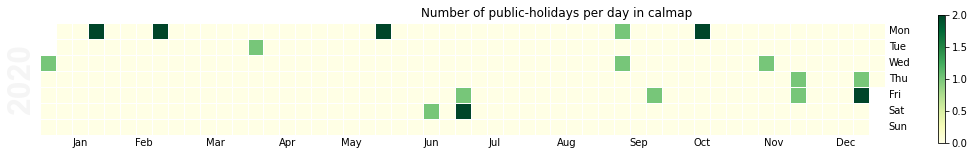

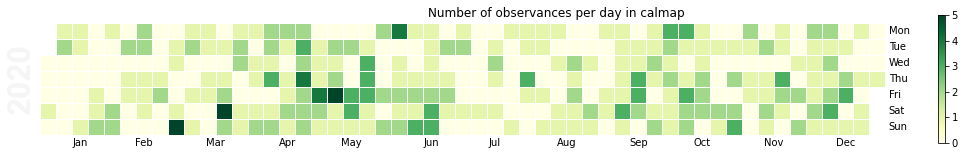

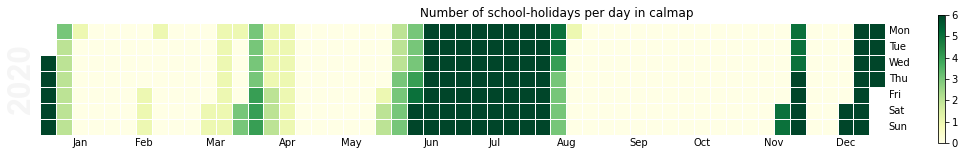

In [10]:
fig, ax = calmap.calendarplot(event_count_per_day["public-holidays"], cmap="YlGn")
fig.set_size_inches(18, 2)
fig.colorbar(ax[0].get_children()[1], ax=ax.ravel().tolist())
_ = fig.suptitle("Number of public-holidays per day in calmap")

fig, ax = calmap.calendarplot(event_count_per_day["observances"], cmap="YlGn")
fig.set_size_inches(18, 2)
fig.colorbar(ax[0].get_children()[1], ax=ax.ravel().tolist())
_ = fig.suptitle("Number of observances per day in calmap")

fig, ax = calmap.calendarplot(event_count_per_day["school-holidays"], cmap="YlGn")
fig.set_size_inches(18, 2)
fig.colorbar(ax[0].get_children()[1], ax=ax.ravel().tolist())
_ = fig.suptitle("Number of school-holidays per day in calmap")


#### Interesting days 
The days in the dataset that have multiple categories with events starting on that day, where there are the most total events.

In [11]:
days_with_multiple_events = event_df.groupby("start_date").count()[["id"]]
multi_events = days_with_multiple_events[days_with_multiple_events["id"]>3].index.tolist()

days_with_multiple_categories = event_df.groupby("start_date").category.nunique().reset_index()
multi_cat = days_with_multiple_categories[days_with_multiple_categories["category"]>=2].start_date.tolist()

event_df[event_df.start_date.isin(multi_events) & event_df.start_date.isin(multi_cat)].groupby(
    ["start_date", "title"]
).count()[
    []
]  

Empty DataFrame
Columns: []
Index: [(2020-03-28, Alhambra Unified School District - Spring Break), (2020-03-28, Earth Hour), (2020-03-28, Pasadena Unified School District - Spring Break), (2020-03-28, South Pasadena Unified School District - Spring Break), (2020-05-25, African Liberation Day), (2020-05-25, Decoration Day), (2020-05-25, Memorial Day), (2020-05-25, National Missing Children's Day), (2020-06-20, American Eagle Day), (2020-06-20, June Solstice), (2020-06-20, Juneteenth National Freedom Day), (2020-06-20, World Refugee Day), (2020-11-21, Alhambra Unified School District - Thanksgiving Break), (2020-11-21, Glendale Unified School District - Thanksgiving Break), (2020-11-21, Montebello Unified School District - Thanksgiving Break), (2020-11-21, Pasadena Unified School District - Thanksgiving Break), (2020-11-21, South Pasadena Unified School District - Thanksgiving Break), (2020-11-21, World Television Day)]

<a id='event_labels'></a>
# Event Label Statistics
Each event is associated with a label. Depending on your business domain, events associated with certain labels may be more or less important.

In [12]:
event_df[["title", "description", "start", "end", "labels"]].head(n=10)

,title,description,start,end,labels
415,Pasadena Unified School District - Christmas B...,,2019-12-20 00:00:00+00:00,2020-01-05 23:59:59+00:00,"[holiday, school]"
410,South Pasadena Unified School District - Chris...,,2019-12-21 00:00:00+00:00,2020-01-05 23:59:59+00:00,"[holiday, school]"
411,Los Angeles Unified School District - Christma...,,2019-12-21 00:00:00+00:00,2020-01-12 23:59:59+00:00,"[holiday, school]"
414,Montebello Unified School District - Christmas...,,2019-12-21 00:00:00+00:00,2020-01-13 23:59:59+00:00,"[holiday, school]"
413,Glendale Unified School District - Christmas B...,,2019-12-21 00:00:00+00:00,2020-01-06 23:59:59+00:00,"[holiday, school]"
412,Alhambra Unified School District - Christmas B...,,2019-12-21 00:00:00+00:00,2020-01-05 23:59:59+00:00,"[holiday, school]"
409,New Year's Day,New Year's Day is the first day of the Gregori...,2020-01-01 00:00:00+00:00,2020-01-01 23:59:59+00:00,"[holiday, holiday-national]"
408,World Braille Day,World Braille Day celebrates the life and achi...,2020-01-04 00:00:00+00:00,2020-01-04 23:59:59+00:00,"[holiday, observance, observance-united-nations]"
407,Epiphany,Many people in the United States annually obse...,2020-01-06 00:00:00+00:00,2020-01-06 23:59:59+00:00,"[holiday, holiday-christian, holiday-religious..."
406,Orthodox Christmas Day,Many Orthodox Christian churches in countries ...,2020-01-07 00:00:00+00:00,2020-01-07 23:59:59+00:00,"[holiday, holiday-orthodox, holiday-religious,..."


In [13]:
label_all = []

for labels in event_df["labels"].to_list():
    label_all.extend(labels)

bins, counts = np.unique(label_all, return_counts=True)

fig = px.bar(x=bins, y=counts, labels={"x": "label", "y": "count"})

fig.update_layout(
    yaxis_type="log",
    title="Frequency of Each Label",
    title_x=0.45,
)

fig.show()

The label information is helpful for understanding the difference between events from each category. For example, the events from *observances* could be further grouped by whether it is a worldwide event or not. With this level of granularity, you can prioritize events from particular labels. 

<a id='ranks'></a>
# PHQ Rank and Aviation Rank

Each Non-Attendance-Based Event has both PHQ Rank and Aviation Rank. 
For observances and public holidays, the PHQ rank is decided by the importance of the holiday - national holidays are ranked higher and local observances are ranked lower.
For US and UK school holidays, the PHQ rank is determined by the number of students which reside in the school district. For all other countries, school holidays have a PHQ rank of 90.

In [14]:
event_df.groupby(["category", "rank"]).count()[["title"]].rename(
    columns={"title": "count"}
)

count
category        rank       
observances     50      359
                90        3
public-holidays 70       11
                90       12
school-holidays 62        6
                74        5
                78        5
                79        5
                80        5
                100       5

Event label and duration are the two main factors for estimating the Aviation Rank.
For school holidays in the UK and the USA, the phq attendance (student numbers) is the main factor in estimating the Aviation Rank.

In [15]:

event_df.groupby(["category", "aviation_rank"]).count()[["title"]].rename(
    columns={"title": "count"}
)

count
category        aviation_rank       
observances     0                362
public-holidays 0                 11
                100               12
school-holidays 0                 26
                85                 5

<a id='duration'></a>
# Duration
Most of the events have one day duration. School holidays usually have multiple days duration.

In [16]:
df = px.data.tips()

fig = px.histogram(
    event_df,
    x="duration_day",
    marginal="box",  # can be 'rug' `box`, `violin`
    hover_data=["id", "title", "category", "labels"],
    nbins=50,
)

fig.update_layout(
    yaxis_type="log",
    title_text="Duration of Events",  # title of plot
    title_x=0.5,
    xaxis_title_text="days",  # xaxis label
    yaxis_title_text="count",  # yaxis label
    bargap=0.2,  # gap between bars of adjacent location coordinates
    bargroupgap=0.1,  # gap between bars of the same location coordinates
)

fig.show()

#### Longest Events

In [17]:
event_df[event_df.duration_day > 20][["title", "start", "end", "category","duration_day"]].sort_values(
    by='duration_day', ascending=False)

,title,start,end,category,duration_day
239,Alhambra Unified School District - Summer Break,2020-05-30 00:00:00+00:00,2020-08-11 23:59:59+00:00,school-holidays,74
241,Pasadena Unified School District - Summer Break,2020-05-29 00:00:00+00:00,2020-08-09 23:59:59+00:00,school-holidays,73
230,South Pasadena Unified School District - Summe...,2020-06-04 00:00:00+00:00,2020-08-12 23:59:59+00:00,school-holidays,70
223,Glendale Unified School District - Summer Break,2020-06-11 00:00:00+00:00,2020-08-16 23:59:59+00:00,school-holidays,67
219,Montebello Unified School District - Summer Break,2020-06-12 00:00:00+00:00,2020-08-16 23:59:59+00:00,school-holidays,66
218,Los Angeles Unified School District - Summer B...,2020-06-13 00:00:00+00:00,2020-08-17 23:59:59+00:00,school-holidays,66
414,Montebello Unified School District - Christmas...,2019-12-21 00:00:00+00:00,2020-01-13 23:59:59+00:00,school-holidays,24
10,Montebello Unified School District - Christmas...,2020-12-19 00:00:00+00:00,2021-01-11 23:59:59+00:00,school-holidays,24
411,Los Angeles Unified School District - Christma...,2019-12-21 00:00:00+00:00,2020-01-12 23:59:59+00:00,school-holidays,23
11,Los Angeles Unified School District - Christma...,2020-12-19 00:00:00+00:00,2021-01-10 23:59:59+00:00,school-holidays,23


<a id='first_seen_date_start_date'></a>
# First Seen Date

Each event has the first_seen_date field which is the time when we have this record. Here are the stats of first seen dates with the most Non-Attendance-Based Events:

In [18]:
event_df.groupby(["first_seen_date"]).count()[["id"]].rename(
    columns={"id": "count"}
).sort_values("count", ascending=False).head()

,count
first_seen_date,
2017-01-04,285
2021-07-28,39
2021-08-13,25
2017-05-11,12
2021-10-12,6


#### Stats of days before the first time seen

Based on the first_seen_date and the start time of the events, we could estimate how many days we could know before the event starts. 

In [19]:
df = px.data.tips()

fig = px.histogram(
    event_df,
    x="day_from_first_seen",
    marginal="box",  # can be 'rug' `box`, `violin`
    hover_data=["id", "title", "category", "labels"],
    nbins=50,
)

fig.update_layout(
    title_text="Number of days between first time seen and start_time",  # title of plot
    title_x=0.5,
    xaxis_title_text="Days before",  # xaxis label
    yaxis_title_text="Count",  # yaxis label
    bargap=0.2,  # gap between bars of adjacent location coordinates
    bargroupgap=0.1,  # gap between bars of the same location coordinates
)

fig.show()

From the histogram, we could see that the majority Non-Attendance-Based Events were listed 3 to 4 years before events started. The main reason is the majority of Non-Attendance-Based Events were listed on 2017-01-04.
There are also several events that were recorded after the event date. This is due to improving school holiday coverage in 2021 and backdating the change to 2020 events. 

####  Some events which were recorded after they happened

In [20]:
event_df[event_df.day_from_first_seen < 0][
    [
        "title",
        "start",
        "end",
        "category",
        "first_seen",
        "day_from_first_seen",
    ]
].head()

,title,start,end,category,first_seen,day_from_first_seen
415,Pasadena Unified School District - Christmas B...,2019-12-20 00:00:00+00:00,2020-01-05 23:59:59+00:00,school-holidays,2021-08-13 05:21:29+00:00,-585
410,South Pasadena Unified School District - Chris...,2019-12-21 00:00:00+00:00,2020-01-05 23:59:59+00:00,school-holidays,2021-08-13 05:19:29+00:00,-585
411,Los Angeles Unified School District - Christma...,2019-12-21 00:00:00+00:00,2020-01-12 23:59:59+00:00,school-holidays,2021-08-13 06:51:38+00:00,-578
414,Montebello Unified School District - Christmas...,2019-12-21 00:00:00+00:00,2020-01-13 23:59:59+00:00,school-holidays,2021-08-13 06:53:40+00:00,-577
413,Glendale Unified School District - Christmas B...,2019-12-21 00:00:00+00:00,2020-01-06 23:59:59+00:00,school-holidays,2021-08-13 05:18:08+00:00,-584


<a id='visual_map'></a>
# Map Visualization

Non-Attendance-Based Events generally have a large location scope. For public holidays and observances, there are two unique locations for the above events. The two locations represent events that are country wide, and events that are state wide.
For the US and UK, school holiday locations represent the school districts in the US and local education authorities in the UK. For all other countries, the school holidays are at a regional or national level

#### Locations of public holidays and observances

In [21]:
def place_id_to_location_name(place_id):
    """
    Convert place_id to location name
    """
    response = requests.get(
        url="https://api.predicthq.com/v1/places/",
        headers={
            "Authorization": "Bearer {}".format(ACCESS_TOKEN),
            "Accept": "application/json",
        },
        params={"id": place_id},
    )

    data = response.json()
    df = pd.json_normalize(data["results"])
    return df.iloc[0]["name"]


event_df["place_hierarchies"] = event_df["place_hierarchies"].apply(lambda x: str(x))

event_df_place_id = (
    event_df[event_df['category'] != 'school-holidays'].groupby(["place_hierarchies"])
    .count()[["id"]]
    .rename(columns={"id": "count"})
    .reset_index()
)

file_name = f"data/place_id_{latitude}_{longitude}_{start_time}_{end_time}.csv"

if RUN_SETTING == "SDK":
    event_df_place_id["location"] = event_df_place_id.place_hierarchies.apply(
        lambda x: place_id_to_location_name(eval(x)[-1])
    )

    event_df_place_id.to_csv(file_name, index=False)
    display(event_df_place_id[["location", "place_hierarchies", "count"]])
else:
    event_df_place_id = pd.read_csv(file_name)
    display(event_df_place_id[["location", "place_hierarchies", "count"]])



,location,place_hierarchies,count
0,California,"[['6295630', '6255149', '6252001', '5332921']]",15
1,United States,"[['6295630', '6255149', '6252001']]",370


We have 15 state wide public holidays and observances and 370 nationwide ones.

#### Locations of school holidays

Since we set our radius to 10km,
the map will show all school districts that overlap the 10km radius around the lat/lon that we queried.
This radius is shown by the red circle on the map.

In [22]:
sh_df = event_df[event_df['category'] == 'school-holidays']

if RUN_SETTING == "SDK":
    sh_df2 = pd.concat([sh_df.drop(['geo'], axis=1), sh_df['geo'].apply(pd.Series)], axis=1)
else:
    def parse_geom(geom_str):
        try:
            return shape(json.loads(geom_str))
        except (TypeError, AttributeError):  # Handle NaN and empty strings
            return None
    sh_df["geo"] = sh_df["geo"].replace(
        "^{'geometry': ","",regex=True).replace(
        "}$","",regex=True).replace(
        "\'", "\"",regex=True)
    sh_df["geo"] = sh_df["geo"].apply(parse_geom)
    
    sh_df2 = gpd.GeoDataFrame(sh_df, geometry="geo")
    sh_df2 = sh_df2.rename(columns={'geo': 'geometry'})
    
    print(sh_df2.columns)
sh_df2['shape'] = sh_df2.apply(lambda x: shape(x['geometry']),axis=1)


#### Visualization of school holidays in map

In [23]:
m = folium.Map(location=[34.07, -118.25], zoom_start=10, tiles='CartoDB positron')
for _, r in sh_df2.iterrows():
    # Without simplifying the representation of each borough,
    # the map might not be displayed
    sim_geo = gpd.GeoSeries(r['shape']).simplify(tolerance=0.001)
    geo_j = sim_geo.to_json()
    geo_j = folium.GeoJson(data=geo_j,
                           style_function=lambda x: {'fillColor': 'orange'})
    folium.Popup(r['title']).add_to(geo_j)
    geo_j.add_to(m)
    folium.Circle(
    radius=10000,
    location=[34.07, -118.25],
    color="crimson",
    fill=False,
).add_to(m)
m

#### Visualization of public holiday and observance locations in map

In [24]:
style1 = {"fillColor": "#228B22", "color": "#228B22"}
style2 = {"fillColor": "#226a8b", "color": "#226a8b"}
# Default location for folium map visualization
lat_folium, lon_folium = 37.0902, -95.7129
# Location for state such as California
lat_state, lon_state = 36.778261, -119.417932
state_name = "California"
# Location for a country such as USA
lat_country, lon_country = 37.09024, -95.712891
country_name = "USA"

m = folium.Map(location=[lat_folium, lon_folium], zoom_start=4.2)
# Add polygon for California
with open("data/geo_data/us-state-boundaries.geojson") as f:
    states = json.load(f)
with open("data/geo_data/countries.geojson") as f:
    countries = json.load(f)

res_state = []

for i in states["features"]:
    if i["properties"]["name"] == state_name:
        res_state.append(i)

polygon1 = states.copy()
polygon1["features"] = res_state

res_country = []

for i in countries["features"]:
    if i["properties"]["ISO_A3"] == country_name:
        res_country.append(i)

polygon2 = countries.copy()
polygon2["features"] = res_country

m = folium.Map(location=[lat_folium, lon_folium], zoom_start=4.2)

folium.Marker(
    location=[lat_state, lon_state],
    popup=state_name,
    icon=folium.Icon(color="green"),
).add_to(m)

folium.GeoJson(polygon1, name=state_name, style_function=lambda x: style1).add_to(m)

folium.Marker(
    location=[lat_country, lon_country],
    popup=country_name,
    icon=folium.Icon(color="blue"),
).add_to(m)

folium.GeoJson(polygon2, name=country_name, style_function=lambda x: style2).add_to(m)

folium.LayerControl().add_to(m)

m

#### Visualize Non-Attendance-Based Events for different regions

Holiday info from neighbouring regions is useful for evaluating the impact of Non-Attendance-Based Events of the day. We use the US as an example. For a given day and specified categories, a map is used to show whether each state has Non-Attendance-Based Events. 

In [25]:

def non_attendance_based_event_state(
    date,
    categories=None
):
    """
    Check whether there are Non-Attendance-Based Events for each state. The visualization is only for US states
    Args:
        date: The date which is interested for checking
                    Format "YYYY-MM-DD"
        categories: list of categories, such as
                                    ['school-holidays',
                                    'public-holidays',
                                    'observances']
    return:
        state_holiday_indicator: dictionary where the keys are the state name and the value indicates whether it has
                                 Non-Attendance-Based Events for specific day
    """

    if categories is None:
        categories = ['public-holidays', 'observances']

    parameters_dict = dict()
    parameters_dict.update(active__gte=date)
    parameters_dict.update(active__lte=date)
    parameters_dict.update(category=categories)

    state_holiday_indicator = {}

    for i in states["features"]:
        state = i["properties"]["name"]
        response = requests.get(
            url="https://api.predicthq.com/v1/places/",
            headers={
                "Authorization": "Bearer {}".format(ACCESS_TOKEN),
                "Accept": "application/json",
            },
            params={"q": state, "type": "region"},
        )

        data = response.json()
        df = pd.json_normalize(data["results"])
        place_id = [int(df.iloc[0]["id"])]
        parameters_dict.update(place__scope=place_id)
        result_list = []

        # Iterating through all the events that match our criteria and adding them to our result_list
        for event in phq.events.search(**parameters_dict).iter_all():
            result_list.append(event.model_dump())

        if len(result_list) > 0:
            state_holiday_indicator[state] = 1
        else:
            state_holiday_indicator[state] = 0

    return state_holiday_indicator


date_map = "2020-11-27"
categories_date = ["public-holidays"]
file_name = f"data/state_holiday_indicator_{date_map}_{'_'.join(categories_date)}.csv"

if RUN_SETTING == "SDK":
    state_holiday_indicator = non_attendance_based_event_state(
        date_map, categories_date
    )
    pd.DataFrame([state_holiday_indicator]).to_csv(
        file_name, index=False
    )
else:
    state_holiday_indicator = (
        pd.read_csv(file_name).T[0].to_dict()
    )


In [26]:
def state_to_color(feature):
    style = styles[state_holiday_indicator[feature["properties"]["name"]]]
    return style


style0 = {"fillColor": "#6da895", "color": "#6da895"}
style1 = {"fillColor": "#2e07f2", "color": "#2e07f2"}
styles = {0: style0, 1: style1}

m = folium.Map(location=[lat_folium, lon_folium], zoom_start=4.2)

folium.Marker(
    location=[latitude, longitude],
    popup="Los Angeles",
    icon=folium.Icon(color="green"),
).add_to(m)

folium.GeoJson(
    states,
    name="California",
    style_function=lambda feature: state_to_color(feature),
).add_to(m)

folium.LayerControl().add_to(m)

m

For the above example, the event info is for the day of ```2020-11-27``` and the category of ```public-holidays```. The pin shows the location of interest in Los Angeles. The states with blue color means they have ```public-holidays``` events on that day. The states with light green color means they do not have ```public-holidays``` events on that day. For states with ```public-holidays``` events, the holiday event is ```Day After Thanksgiving```. The visualization means that around half of the states have ```public-holidays``` events on ```Day After Thanksgiving```.

# Visualizing School Districts

Here we have chosen the day  ```2020-12-23``` and the category of ```school-holidays``` for the state of Montana.
The resulting map shows that on this day, some districts in Montana have an active school holiday, the uncolored areas represent the areas of school districts that are not on holiday for this particular day. The areas of the school districts are represented by polygons which can be found in the ```geo``` field.

In [27]:
# FOR RUN SETTING == SDK

mont_parameters = dict()
place_ids = 5667009 #Montana place_id
mont_parameters.update(place__scope=place_ids)

start_time = "2020-12-23"
end_time = "2020-12-23"
mont_parameters.update(active__gte=start_time)
mont_parameters.update(active__lte=end_time)

timezone = "America/Denver"
mont_parameters.update(active__tz=timezone)

categories = ["school-holidays"]
mont_parameters.update(category=categories)

mont_results = []

# Iterating through all the events that match our criteria and adding them to our results
for event in phq.events.search(mont_parameters).iter_all():
    mont_results.append(event.model_dump())

# Converting the results to a DataFrame
montana_school_holiday_df = pd.DataFrame(mont_results)
montana_school_holiday_df = montana_school_holiday_df[
            ["id",
            "title",
            "description",
            "start",
            "end",
            "duration",
            "category",
            "labels",
            "country",
            "rank",
            "aviation_rank",
            "phq_attendance",
            "geo",
            "local_rank",
            "location",
            "place_hierarchies",
            "scope",
            "first_seen"]
        ]

In [28]:
# IF RUN SETTING = CSV, Uncomment
# montana_school_holiday_df = pd.read_csv(f"data/event_data/montana_school_holidays_2020-12-23.csv")

In [29]:
if RUN_SETTING == "SDK":
    mont_df = pd.concat([montana_school_holiday_df.drop(['geo'], axis=1), montana_school_holiday_df['geo'].apply(pd.Series)], axis=1)
else:
    def parse_geom(geom_str):
        try:
            return shape(json.loads(geom_str))
        except (TypeError, AttributeError):  # Handle NaN and empty strings
            return None
    montana_school_holiday_df["geo"] = montana_school_holiday_df["geo"].replace(
        "^{'geometry': ","",regex=True).replace(
        "}$","",regex=True).replace(
        "\'", "\"",regex=True)
    
     
    montana_school_holiday_df["geo"] = montana_school_holiday_df["geo"].apply(parse_geom)
    #print(montana_school_holiday_df["geo"])
    mont_df = gpd.GeoDataFrame(montana_school_holiday_df, geometry="geo")
    #print(mont_df["geo"])
    mont_df = mont_df.rename(columns={'geo': 'geometry'})
    

mont_df['shape'] = mont_df.apply(lambda x: shape(x['geometry']),axis=1)

In [30]:
m2 = folium.Map(location=[46.8797, -110.3626], zoom_start=6, tiles='CartoDB positron')
for _, r in mont_df.iterrows():
    # Without simplifying the representation of each borough,
    # the map might not be displayed
    sim_geo = gpd.GeoSeries(r['shape']).simplify(tolerance=0.001)
    geo_j = sim_geo.to_json()
    geo_j = folium.GeoJson(data=geo_j,
                           style_function=lambda x: {'fillColor': 'orange'})
    folium.Popup(r['title']).add_to(geo_j)
    geo_j.add_to(m).add_to(m2)
m2

<a id='radius_impact'></a>
# Impact of Radius Settings

Events info is summarized for a range of radii: 1km, 2km, 4km, 8km, 16km, 32km, 64km, 128km, 256km, 512km and 1024km.

In [31]:
# Results of stats for different radius
res_stat = []
# Results of DataFrame for different radius
res_df = []
start_time = "2020-01-01"
end_time = "2020-12-31"
radius_unit = "km"
latitude, longitude = (34.07, -118.25)
categories = ["school-holidays", "public-holidays", "observances"]

for radius_impact in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]:
    file_name = f"data/event_data/radius{radius_impact}{radius_unit}_{latitude}_{longitude}_{start_time}_{end_time}.csv"

    if RUN_SETTING == "SDK":
        event_df_radius = query_unattended_events(
            start_time,
            end_time,
            radius_impact,
            radius_unit,
            latitude,
            longitude,
            categories,
        )

        event_df_radius.to_csv(
            file_name,
            index=False,
        )

        # Convert to string since list not hashable.
        event_df_radius["place_hierarchies"] = event_df_radius[
            "place_hierarchies"
        ].apply(lambda x: str(x))
    else:
        event_df_radius = pd.read_csv(file_name)

    stat = event_df_radius.groupby(["category"])["title"].count().to_dict()
    stat["radius"] = radius_impact
    res_stat.append(stat)

    event_df_radius["radius"] = f"{radius_impact}{radius_unit}"
    res_df.append(event_df_radius)

res_stat = pd.DataFrame(res_stat)

fig = go.Figure()

fig.add_trace(go.Scatter(x=res_stat.radius, y=res_stat.observances, name="observances"))

fig.add_trace(
    go.Scatter(x=res_stat.radius, y=res_stat["public-holidays"], name="public-holidays")
)

fig.add_trace(
    go.Scatter(x=res_stat.radius, y=res_stat["school-holidays"], name="school-holidays")
)

fig.update_layout(
    xaxis_type="log",
    yaxis_type="log",
    title="Number of events for different radius",
    title_x=0.45,
    xaxis=dict(
        title="radius (km)",
    ),
    yaxis=dict(
        title="count",
    ),
)

fig.show()

In [32]:
m = folium.Map(location=[latitude, longitude], zoom_start=4.2)
folium.Marker(location=[latitude, longitude]).add_to(m)

for radius_impact in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]:
    folium.Circle(
        [latitude, longitude],
        radius=radius_impact * 1000,
        tooltip=f"{radius_impact}{radius_unit}",
    ).add_to(m)

m

##### Stats of public holiday and observance events per radius setting

In [33]:
file_name = f"data/radius_pivot_{latitude}_{longitude}_{start_time}_{end_time}.csv"

if RUN_SETTING == "SDK":
    event_df_radius_all = pd.concat(res_df)[
        ["title", "place_hierarchies", "radius", "category","id"]
    ]
    
    event_df_radius_all_count = (
        event_df_radius_all[event_df_radius_all['category'] != 'school-holidays'].groupby(["radius", "place_hierarchies"])
        .count()[["id"]]
        .rename(columns={"id": "count"})
        .reset_index()
    )

    event_df_radius_all_count[
        "location"
    ] = event_df_radius_all_count.place_hierarchies.apply(
        lambda x: place_id_to_location_name(eval(x)[-1])
    )
    


    radius_column = [
        f"{radius_impact}{radius_unit}"
        for radius_impact in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
    ]
    
    event_df_radius_all_count_pivot = (
        event_df_radius_all_count.pivot(
            index="location", columns="radius", values="count"
        )
        .fillna(0)[radius_column]
        .sort_values(radius_column, ascending=False)
    )
    
    event_df_radius_all_count_pivot.to_csv(
        file_name
    )
    
    display(event_df_radius_all_count_pivot.astype(int))
else:
    event_df_radius_all_count_pivot = pd.read_csv(
        file_name
    )
    
    display(event_df_radius_all_count_pivot.set_index("location").astype(int))


radius,1km,2km,4km,8km,16km,32km,64km,128km,256km,512km,1024km
location,,,,,,,,,,,
United States,370,370,370,370,370,370,370,370,370,370,370
California,15,15,15,15,15,15,15,15,15,15,15
Arizona,0,0,0,0,0,0,0,0,0,0,17
Utah,0,0,0,0,0,0,0,0,0,0,11
Nevada,0,0,0,0,0,0,0,0,0,0,10


#### Additional events for radius 1024

In [34]:
event_df_radius_512km = res_df[-2]
event_df_radius_1024km = res_df[-1]
event_df_radius = pd.concat([event_df_radius_512km, event_df_radius_1024km])[
    [
        "id",
        "title",
        "description",
        "start",
        "end",
        "duration",
        "category",
        "country",
        "place_hierarchies",
        "rank",
        "aviation_rank",
    ]
]

event_df_radius[event_df_radius['category'] != 'school-holidays'].drop_duplicates(keep=False)[
    ["id", "title", "start", "end", "category", "place_hierarchies"]
]

,id,title,start,end,category,place_hierarchies
3,9BcecomvE97yjCgGmQ,Christmas Day,2020-12-25 00:00:00+00:00,2020-12-25 23:59:59+00:00,public-holidays,"[['6295630', '6255149', '6252001', '5551752']]"
1148,rwFciChCgEK4BTi2A5,Family Day,2020-11-27 00:00:00+00:00,2020-11-27 23:59:59+00:00,public-holidays,"[['6295630', '6255149', '6252001', '5509151']]"
2294,rRqxD6WgAwBE,Nevada Day,2020-10-30 00:00:00+00:00,2020-10-30 23:59:59+00:00,public-holidays,"[['6295630', '6255149', '6252001', '5509151']]"
2389,6uAUiZUzwp5ZE2WUBH,Columbus Day,2020-10-12 00:00:00+00:00,2020-10-12 23:59:59+00:00,public-holidays,"[['6295630', '6255149', '6252001', '5551752']]"
2390,84ZyN4ikXhKLYkuhg5,Indigenous People's Day,2020-10-12 00:00:00+00:00,2020-10-12 23:59:59+00:00,public-holidays,"[['6295630', '6255149', '6252001', '5551752']]"
2392,ArFWF9zAV4rhpKEvyD,Indigenous People's Day,2020-10-12 00:00:00+00:00,2020-10-12 23:59:59+00:00,public-holidays,"[['6295630', '6255149', '6252001', '5549030']]"
2394,Hp3bp7aqCsfYwwhnpP,Indigenous People's Day,2020-10-12 00:00:00+00:00,2020-10-12 23:59:59+00:00,public-holidays,"[['6295630', '6255149', '6252001', '5509151']]"
2395,c8viFTCsnFZQdFAT6F,Columbus Day,2020-10-12 00:00:00+00:00,2020-10-12 23:59:59+00:00,public-holidays,"[['6295630', '6255149', '6252001', '5549030']]"
2635,E2EKMwpmcKkyvWsMmo,Native American Day,2020-09-25 00:00:00+00:00,2020-09-25 23:59:59+00:00,public-holidays,"[['6295630', '6255149', '6252001', '5509151']]"
2659,oj72BXW4AugzLVSWAf,Constitution Commemoration Day,2020-09-13 00:00:00+00:00,2020-09-13 23:59:59+00:00,public-holidays,"[['6295630', '6255149', '6252001', '5551752']]"


From the previous plot we can see that as we increase the radius, we include more school districts and add to the number of school holiday events. 
For public holidays and observances, we have to wait for the radius to increase until it has overlap with neighbouring states in order to include extra events. This is because the events in those categories are at the state level or national level. Once we reach 1024km away from our intial point, we reach some neighbouring states and add state level events. 

<a id='comparing_with_third_party_libraries'></a>
# Comparing with Third Party Libraries

Holiday info from three third party libraries has been compared with events from the PredictHQ public-holidays category.

### Holiday from Pandas
Pandas has the ability for us to check whether a particular day is a holiday.

In [35]:
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

dr = pd.date_range(start="2020-01-01", end="2020-12-31")
holiday_pandas = pd.DataFrame()
holiday_pandas["Date"] = dr

cal = calendar()
holidays = cal.holidays(start=dr.min(), end=dr.max())

holiday_pandas["Holiday"] = holiday_pandas["Date"].isin(holidays)
holiday_pandas[holiday_pandas.Holiday]

,Date,Holiday
0,2020-01-01,True
19,2020-01-20,True
47,2020-02-17,True
145,2020-05-25,True
184,2020-07-03,True
250,2020-09-07,True
285,2020-10-12,True
315,2020-11-11,True
330,2020-11-26,True
359,2020-12-25,True


### Holidays from Facebook Prophet
Modelling the impact of holidays on time series data is an important component in Prophet. Inside Prophet, the holiday information is provided by the *holidays* package in Python, but the holiday information is only available at the country level.

In [36]:
from fbprophet.make_holidays import make_holidays_df

holiday_prophet = make_holidays_df(year_list=[2020], country="US")
holiday_prophet

,ds,holiday
0,2020-01-01,New Year's Day
1,2020-01-20,Martin Luther King Jr. Day
2,2020-02-17,Washington's Birthday
3,2020-05-25,Memorial Day
4,2020-07-04,Independence Day
5,2020-07-03,Independence Day (Observed)
6,2020-09-07,Labor Day
7,2020-10-12,Columbus Day
8,2020-11-11,Veterans Day
9,2020-11-26,Thanksgiving


### Holidays From Python
The *holidays* package in Python provides holiday information. For example, it provides holiday information for each state in the US.

In [37]:
import holidays

holiday_holidays = []
for date, name in sorted(holidays.US(state="CA", years=2020).items()):
    holiday_holidays.append({"date": date, "holiday_holidays": name})

holiday_holidays = pd.DataFrame(holiday_holidays)
holiday_holidays

,date,holiday_holidays
0,2020-01-01,New Year's Day
1,2020-01-20,Martin Luther King Jr. Day
2,2020-02-15,Susan B. Anthony Day
3,2020-02-17,Washington's Birthday
4,2020-03-31,César Chávez Day
5,2020-05-25,Memorial Day
6,2020-07-03,Independence Day (Observed)
7,2020-07-04,Independence Day
8,2020-09-07,Labor Day
9,2020-10-12,Columbus Day


### The *public-holidays* info from PredictHQ

In [38]:
event_df[event_df.category == "public-holidays"].sort_values("start")[
    ["title", "start", "end", "rank", "aviation_rank"]
]

,title,start,end,rank,aviation_rank
409,New Year's Day,2020-01-01 00:00:00+00:00,2020-01-01 23:59:59+00:00,90,100
401,Robert E. Lee's Birthday,2020-01-20 00:00:00+00:00,2020-01-20 23:59:59+00:00,70,0
400,Martin Luther King Jr. Day,2020-01-20 00:00:00+00:00,2020-01-20 23:59:59+00:00,90,100
378,Presidents' Day,2020-02-17 00:00:00+00:00,2020-02-17 23:59:59+00:00,70,0
377,Presidents' Day,2020-02-17 00:00:00+00:00,2020-02-17 23:59:59+00:00,90,100
333,César Chávez Day,2020-03-31 00:00:00+00:00,2020-03-31 23:59:59+00:00,70,0
246,Decoration Day,2020-05-25 00:00:00+00:00,2020-05-25 23:59:59+00:00,70,0
244,Memorial Day,2020-05-25 00:00:00+00:00,2020-05-25 23:59:59+00:00,90,100
207,Juneteenth National Freedom Day,2020-06-20 00:00:00+00:00,2020-06-20 23:59:59+00:00,70,0
191,Day off for Independence Day,2020-07-03 00:00:00+00:00,2020-07-03 23:59:59+00:00,90,100


### The holidays provided by the above libraries are summarized in the following table.

date |pandas |fbprophet | holidays | *public-holidays* (PredictHQ)
:-----:|:-----:|:-----:|:-----:|:-----:
2020-01-01|$\surd$|$\surd$|$\surd$|$\surd$
2020-01-20|$\surd$|$\surd$|$\surd$|$\surd$
2020-02-15|$\times$|$\times$|$\surd$|$\surd$
2020-02-17|$\surd$|$\surd$|$\surd$|$\surd$
2020-03-31|$\times$|$\times$|$\surd$|$\surd$
2020-05-25|$\surd$|$\surd$|$\surd$|$\surd$
2020-07-03|$\surd$|$\surd$|$\surd$|$\surd$
2020-07-04|$\times$|$\surd$|$\surd$|$\surd$
2020-09-07|$\surd$|$\surd$|$\surd$|$\surd$
2020-09-25|$\times$|$\times$|$\times$|$\surd$
2020-10-12|$\surd$|$\surd$|$\surd$|$\surd$
2020-11-11|$\surd$|$\surd$|$\surd$|$\surd$
2020-11-26|$\surd$|$\surd$|$\surd$|$\surd$
2020-11-27|$\times$|$\times$|$\surd$|$\surd$
2020-12-24|$\times$|$\times$|$\times$|$\surd$
2020-12-25|$\surd$|$\surd$|$\surd$|$\surd$

From the above table, we can see the events from *public-holidays* have a wider coverage than the holiday information from other libraries. 

In addition to  *public-holidays*, PredictHQ's Non-Attendance-Based Events also include events from *observances* and *school-holidays*. For the dataset used previously, PredictHQ has $\frac{23+31+362}{15}=27.7$ times more events than the holiday events from the *holidays* package. 

PredictHQ also provides additional rank information to indicate the impact of these events. 

<a id='forecasting_impact'></a>
# Forecasting Impact

Within this notebook, we've gained a better understanding of PredictHQ's Non-Attendance-Based Events (public-holidays, observances and school-holidays).

By using this information we can make better decisions about how to incorporate these data points into forecasting.

Here's a summary of some of the key take-ways from each section. 

- [Overview of Non-Attendance-Based Events](#event_overview)
Of the three categories, observances make up the largest proportion of events. Although school-holidays make up a smaller proportion of the events, these events are usually multi-day events.

- [Event Label Statistics](#event_labels)
Event labels help to provide more detailed understanding of the type of events happening and make it easier to filter for events relevant to your business.

- [PHQ Rank and Local Rank](#ranks)
Rank information indicates the events impact. Aviation Rank indicates the impact on air travel. 

- [Duration](#duration)
School-holidays are the longest events. Most observances are 1 day events.

- [First Seen Date](#first_seen_date_start_date)
Most of the Non-Attendance-Based Events are known much earlier than they are happening. This is important for utilizing Non-Attendance-Based Events in forecasting models. 

- [Map Visualization](#visual_map)
The location of Non-Attendance-Based Events shows these events generally have a large scope. Some events will be at the country level with others at the state level (US). School Holidays in the US are at the school district level.

- [Impact of Radius Settings](#radius_impact)
For business that would be impacted by events from neighbouring regions, the events could be extracted by setting the radius to be a relatively large value.

- [Comparing with Third Party Libraries](#comparing_with_third_party_libraries)
PredictHQ's *public-holidays* has significantly better coverage than other commonly used packages.